# Most of this code is by Savannah Gramze, from filament_COice.ipynb

In [2]:
from astropy.table import Table
import numpy as np
from astropy import units as u

In [3]:
tab = Table.read('https://www.nature.com/articles/s41550-025-02511-z/tables/1', format='ascii.html')
tab[:2]

ID,RA,Dec,\({\boldsymbol{N}}_{{{{\mathbf{H}}}}_{\mathbf{2}}{{\mathbf{O}}}}\),\({\boldsymbol{N}}_{{{{\mathbf{CO}}}}_{{{\mathbf{2}}}}}\),NCO,\(\frac{{{{\mathbf{CO}}}}_{{{\mathbf{2}}}}}{{{{\mathbf{H}}}}_{\mathbf{2}}{{\mathbf{O}}}}\),\(\frac{{{\mathbf{CO}}}}{{{{\mathbf{H}}}}_{\mathbf{2}}{{\mathbf{O}}}}\),\(\frac{{{{\mathbf{CO}}}}_{{{\mathbf{2}}}}}{{{\mathbf{CO}}}}\),\({\boldsymbol{N}}_{{{{\mathbf{H}}}}_{{{\mathbf{2}}}}}\),F410M
str4,float64,str9,str26,str26,str26,str26,str26,str26,float64,float64
13*,166.52798,−77.41515,\(4.8{2}_{-0.67}^{+1.04}\),\(1.5{4}_{-0.08}^{+0.08}\),\(0.8{1}_{-0.66}^{+0.81}\),\(0.3{2}_{-0.05}^{+0.07}\),\(0.1{7}_{-0.14}^{+0.17}\),\(1.9{0}_{-1.55}^{+1.90}\),1.54,0.013
16*,166.53697,−77.41404,\(5.7{5}_{-1.26}^{+1.47}\),\(1.1{8}_{-0.05}^{+0.05}\),\(1.5{5}_{-0.68}^{+0.74}\),\(0.2{1}_{-0.05}^{+0.05}\),\(0.2{7}_{-0.13}^{+0.15}\),\(0.7{6}_{-0.33}^{+0.37}\),1.78,0.012


In [4]:
from pylatexenc.latex2text import LatexNodes2Text
from unidecode import unidecode

ln2 = LatexNodes2Text()
for colname in tab.colnames:

    for row in tab:
        try:
            row[colname] = ln2.latex_to_text(row[colname])
        except:
            pass

    # Convert LaTeX to Unicode, then Unicode to ASCII
    unicode_name = ln2.latex_to_text(colname).replace("_", "")
    ascii_name = unidecode(unicode_name)
    tab.rename_column(colname, ascii_name)


tab[:2]

ID,RA,Dec,NH2O,NCO2,NCO,CO2/H2O,CO/H2O,CO2/CO,NH2,F410M
str4,float64,str9,str26,str26,str26,str26,str26,str26,float64,float64
13*,166.52798,−77.41515,4.82_-0.67^+1.04,1.54_-0.08^+0.08,0.81_-0.66^+0.81,0.32_-0.05^+0.07,0.17_-0.14^+0.17,1.90_-1.55^+1.90,1.54,0.013
16*,166.53697,−77.41404,5.75_-1.26^+1.47,1.18_-0.05^+0.05,1.55_-0.68^+0.74,0.21_-0.05^+0.05,0.27_-0.13^+0.15,0.76_-0.33^+0.37,1.78,0.012


In [5]:
#from astropy.table import Table
#tab = Table.read('tab_dat.csv', delimiter=' ')#.write('tab_dat.fits', format='fits', overwrite=True)
#  (J2000) (J2000) (10^18 cm^−2) (10^18 cm^−2) (10^18 cm^−2)    (10^22 cm^−2) (mJy)
#tab.units = {'RA': u.deg, 'DEC': u.deg, 'F410M': u.mJy}#, 'N_HI': u.cm**-2, 'N_H2': u.cm**-2, 'N_H_tot': u.cm**-2, 'N_H_tot_err': u.cm**-2, 'flux_187': u.mJy}
tab['F410M'].unit = u.mJy
tab['RA'].unit = u.deg
tab['Dec'].unit = u.deg
tab['NH2'].unit = 10**22 * u.cm**-2
tab['NH2O'].unit = 10**18 * u.cm**-2
tab['NCO2'].unit = 10**18 * u.cm**-2
tab['NCO'].unit = 10**18 * u.cm**-2
tab['Av'] = tab['NH2']*10**22 * u.cm**-2 * 2 / (2.21e21 * u.cm**-2)   # Convert to Av using NH2 to Av conversion factor
tab['Av'].unit = u.mag  # Av is in magnitudes
tab[:2]

ID,RA,Dec,NH2O,NCO2,NCO,CO2/H2O,CO/H2O,CO2/CO,NH2,F410M,Av
,deg,deg,1e+18 / cm2,1e+18 / cm2,1e+18 / cm2,,,,1e+22 / cm2,mJy,mag
str4,float64,str9,str26,str26,str26,str26,str26,str26,float64,float64,float64
13*,166.52798,−77.41515,4.82_-0.67^+1.04,1.54_-0.08^+0.08,0.81_-0.66^+0.81,0.32_-0.05^+0.07,0.17_-0.14^+0.17,1.90_-1.55^+1.90,1.54,0.013,13.936651583710407
16*,166.53697,−77.41404,5.75_-1.26^+1.47,1.18_-0.05^+0.05,1.55_-0.68^+0.74,0.21_-0.05^+0.05,0.27_-0.13^+0.15,0.76_-0.33^+0.37,1.78,0.012,16.108597285067873


In [6]:
#tab['NCO']
NCO_ice = np.zeros(len(tab['NCO']))#NCO_ice))#np.array(tab['NCO'])
NCO_poserr = np.zeros_like(NCO_ice)
NCO_negerr = np.zeros_like(NCO_ice)
Av_ice = np.array(tab['Av'])

for i in range(len(NCO_ice)):
    #ele = NCO_ice[i]
    NCO_ice[i] = np.float64(np.array(tab['NCO'])[i].split('_')[0])
    NCO_negerr[i] = np.abs(np.float64(np.array(tab['NCO'])[i].split('_')[1].split("^")[0]))
    NCO_poserr[i] = np.abs(np.float64(np.array(tab['NCO'])[i].split('_')[1].split("^")[1]))

NCO_ice = NCO_ice* 1e18  # Convert to cm^-2 for consistency with other values
NCO_poserr = NCO_poserr* 1e18  # Convert to cm^-2 for consistency with other values
NCO_negerr = NCO_negerr* 1e18  # Convert to cm^-2 for consistency with other values

In [7]:
#https://ui.adsabs.harvard.edu/abs/2012A%26A...539A.143N/abstract
carbon_abundance = 10**(8.3-12)

# https://ui.adsabs.harvard.edu/abs/2021ApJS..252...22Z/abstract
AV_to_NH = 4.60e-22
NH_to_AV = 1/AV_to_NH
NH_to_AV, carbon_abundance

(2.173913043478261e+21, 0.00019952623149688828)

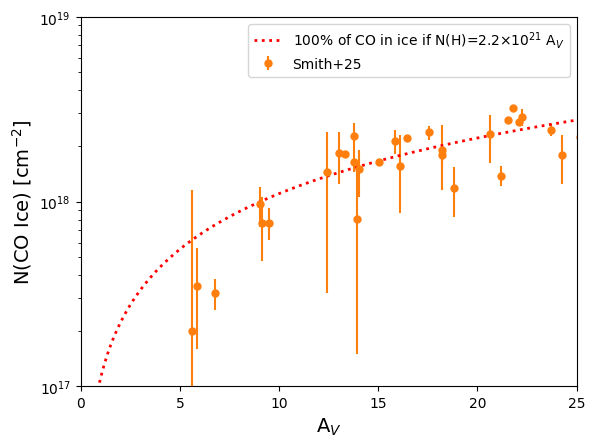

In [8]:
from matplotlib import pyplot as plt
ax = plt.subplot(111)
ax.errorbar(Av_ice, NCO_ice, yerr=[NCO_negerr, NCO_poserr], color='tab:orange', marker='o', markersize=5, linestyle='none', label='Smith+25')
ax.set_yscale('log')
ax.set_xlim(0, 100)
ax.set_ylim(1e17, 4e19)
ax.set_xlabel('A$_V$', fontsize=14)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=14)
NCOofAV = 2.21e21 * np.linspace(0.1, 100, 1000) * carbon_abundance
NCOofAV = 2.21e21 / 2 * np.linspace(0.1, 100, 1000) * 1e-4
ax.plot(np.linspace(0.1, 100, 1000), NCOofAV, lw=2,
            label='100% of CO in ice if N(H)=2.2$\\times10^{21}$ A$_V$', color='r', linestyle=':')
plt.axis([0,25,1e17,1e19]);
ax.legend()
plt.savefig("/orange/adamginsburg/jwst/cloudc/figures/Smith2025_IceVsAV.pdf", bbox_inches='tight')


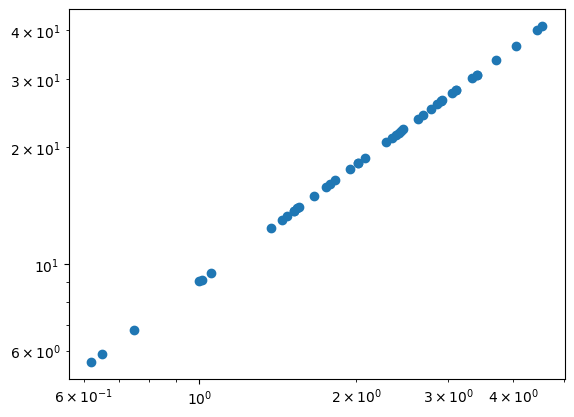

In [12]:
NH2 = tab['NH2'].quantity.to(u.cm**-2)
plt.loglog(NH2 * 1e-22, Av_ice, 'o')

In [ ]:
carbon_abundance = 2.5e-4
ax = plt.subplot(111)
ax.plot([], [], ' ', label='C/H = $2.5\\times10^{-4} = 10^{-3.6}$')
NH2 = tab['NH2'].quantity.to(u.cm**-2)
ax.errorbar(NH2 * 1e-22, NCO_ice * 10**-19, yerr=[NCO_negerr * 10**-19, NCO_poserr * 10**-19],
            color='tab:orange', marker='o', markersize=5, linestyle='none', label='Smith+25')
#ax.set_yscale('log')
#ax.set_ylim(1e17, 4e19)
ax.set_xlabel('N(H$_2$) [$10^{22}$ cm$^{-2}$]', fontsize=14)
ax.set_ylabel('N(CO Ice) [$10^{19}$ cm$^{-2}$]', fontsize=14)
xvals = np.geomspace(1e21, 0.5e23)
# multiply all by 2 bcause X-axis is N(H2)
ax.plot(xvals * 1e-22, xvals * carbon_abundance * 0.5 * 2 * 10**-19, lw=2,
        label='50% of C in CO ice', color='g', linestyle='-.')
ax.plot(xvals * 1e-22, xvals * carbon_abundance * 0.25 * 2 * 10**-19, lw=2,
        label='25% of C in CO ice', color='b', linestyle='--')
ax.plot(xvals * 1e-22, xvals * carbon_abundance * 2 * 10**-19 * 0.1, lw=2,
        label='10% of C in CO ice', color='r', linestyle=':')
ax2 = ax.twiny()
#ax2.set_xscale('log')
ax2.set_xlabel('A$_V$', fontsize=14)
ax2.set_xlim(ax.get_xlim()[0] * AV_to_NH * 2 * 1e22, ax.get_xlim()[1] * AV_to_NH * 2 * 1e22)



ax.set_ylim(0, 0.5)
ax.legend()
plt.savefig("/orange/adamginsburg/jwst/cloudc/figures/Smith2025_IceVsNH2.pdf", bbox_inches='tight')


In [ ]:
carbon_abundance = 2.5e-4
CO_abundance = 1e-4 # CO/H2
ax = plt.subplot(111)
#ax.semilogy([], [], ' ', label='C/H = $2.5\\times10^{-4} = 10^{-3.6}$')
NH2 = tab['NH2'].quantity.to(u.cm**-2)
ax.errorbar(NH2, NCO_ice, yerr=[NCO_negerr, NCO_poserr],
            #color='tab:orange',
            color='k',
            marker='o', markersize=5, linestyle='none', label='Smith+25')
ax.set_yscale('log')
#ax.set_ylim(1e17, 4e19)
ax.set_xlabel('N(H$_2$) [cm$^{-2}$]', fontsize=14)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=14)
xvals = np.geomspace(1e19, 1e23) # these are H2 abundances
# multiply all by 2 bcause X-axis is N(H2)
# ax.plot(xvals, xvals * carbon_abundance * 0.5 * 2, lw=2,
#         label='50% of C in CO ice', color='g', linestyle='-.')
# ax.plot(xvals, xvals * carbon_abundance * 0.20 * 2, lw=2,
#         label='20% of C in CO ice', color='b', linestyle='--')
# ax.plot(xvals, xvals * carbon_abundance * 2 * 0.1, lw=2,
#         label='10% of C in CO ice', color='r', linestyle=':')
ax.plot(xvals, xvals * CO_abundance, lw=2,
        label='CO/H$_2=10^{-4}$', color='r', linestyle='-.')
ax.plot(xvals, xvals * CO_abundance * 2.5, lw=2,
        label='CO/H$_2=2.5 \\times 10^{-4}$', color='r', linestyle=':')
ax.plot(xvals, xvals * CO_abundance * 5, lw=2,
        label='CO/H$_2=5 \\times 10^{-4}$', color='r', linestyle='--')
ax.set_xlim(1e19, 5e22)
ax.set_ylim(5e16, 1e19)
ax2 = ax.twiny()
#ax2.set_xscale('log')
ax2.set_xlabel('A$_V$', fontsize=14)
ax2.set_xlim(ax.get_xlim()[0] * AV_to_NH * 2, ax.get_xlim()[1] * AV_to_NH * 2)


ax.legend()
plt.savefig("/orange/adamginsburg/jwst/cloudc/figures/Smith2025_IceVsNH2_log.pdf", bbox_inches='tight')

In [ ]:
NH2

In [ ]:
(NCO_poserr / NCO_ice)

In [ ]:
np.log10(0.05)